# Re40 PINN domain / residual verification

This notebook checks two things after the code change:

1. **CFD points inside PDE domain**: whether the CFD snapshot points lie inside the reduced PDE training domain.
2. **Residual on CFD points**: evaluate Navier–Stokes residuals at CFD points using the trained checkpoint, then report summary statistics and high-residual fractions.

Update the paths in the next cell before running.


In [15]:
from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PY_FILE = "/oscar/home/jchen790/cylinder flow lab/cfp40.py"
VTK_PATH = "/oscar/home/jchen790/cylinder flow lab/Re40.vtk"
SAVE_DIR = Path('checkpoints_wake_mid')      # <-- change 

XMIN, XMAX = -3.0, 12.0
YMIN, YMAX = -4.0, 4.0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', DEVICE)
print('py file =', PY_FILE)
print('vtk path =', VTK_PATH)
print('save dir =', SAVE_DIR)


device = cpu
py file = /oscar/home/jchen790/cylinder flow lab/cfp40.py
vtk path = /oscar/home/jchen790/cylinder flow lab/Re40.vtk
save dir = checkpoints_wake_mid


In [16]:
spec = importlib.util.spec_from_file_location('re40mod', PY_FILE)
re40mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(re40mod)

snapshot = re40mod.load_single_vtk(str(VTK_PATH), t_value=0.0)
print('num CFD points =', len(snapshot.x))
print('x range =', float(snapshot.x.min()), float(snapshot.x.max()))
print('y range =', float(snapshot.y.min()), float(snapshot.y.max()))


Loaded Re40.vtk  cells=8234
num CFD points = 8234
x range = -9.75 14.75
y range = -9.75 9.75


## 1) Are CFD points inside the PDE domain?

In [17]:
inside = (
    (snapshot.x >= XMIN) & (snapshot.x <= XMAX) &
    (snapshot.y >= YMIN) & (snapshot.y <= YMAX)
)
outside_cyl = ((snapshot.x**2 + snapshot.y**2) >= 0.5**2)

domain_df = pd.DataFrame({
    'metric': ['total CFD points', 'inside PDE box', 'outside cylinder', 'inside PDE fluid domain'],
    'count': [
        int(len(snapshot.x)),
        int(inside.sum()),
        int(outside_cyl.sum()),
        int((inside & outside_cyl).sum())
    ]
})
domain_df['fraction'] = domain_df['count'] / len(snapshot.x)
domain_df


,metric,count,fraction
0,total CFD points,8234,1.000000
1,inside PDE box,4919,0.597401
2,outside cylinder,8184,0.993928
3,inside PDE fluid domain,4869,0.591329


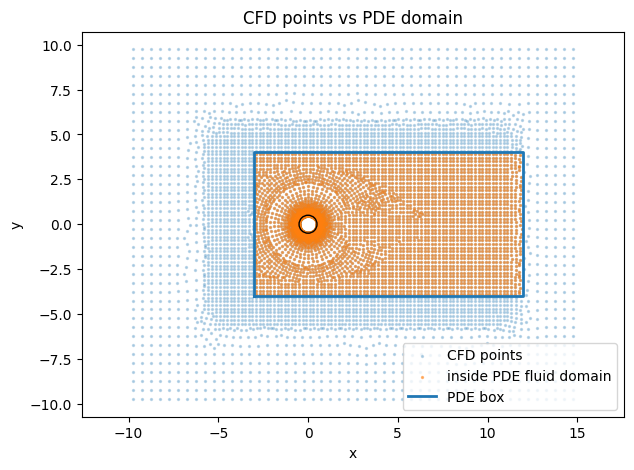

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(snapshot.x, snapshot.y, s=2, alpha=0.25, label='CFD points')
mask = inside & outside_cyl
plt.scatter(snapshot.x[mask], snapshot.y[mask], s=2, alpha=0.5, label='inside PDE fluid domain')
rect_x = [XMIN, XMAX, XMAX, XMIN, XMIN]
rect_y = [YMIN, YMIN, YMAX, YMAX, YMIN]
plt.plot(rect_x, rect_y, linewidth=2, label='PDE box')
circle = plt.Circle((0,0), 0.5, fill=False)
plt.gca().add_patch(circle)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('CFD points vs PDE domain')
plt.legend()
plt.show()


## 2) Residual on CFD points

This uses the checkpoint in `SAVE_DIR`. If you have not trained yet, run the modified `.py` first.


In [19]:
model = re40mod.load_model_for_viz(str(SAVE_DIR), DEVICE, width=96, depth=5)
model.eval()


[viz] loaded checkpoints_wake_mid/pinn_Re40_single.pt


MLPStreamPressure(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=96, bias=True)
    (1): Tanh()
    (2): Linear(in_features=96, out_features=96, bias=True)
    (3): Tanh()
    (4): Linear(in_features=96, out_features=96, bias=True)
    (5): Tanh()
    (6): Linear(in_features=96, out_features=96, bias=True)
    (7): Tanh()
    (8): Linear(in_features=96, out_features=96, bias=True)
    (9): Tanh()
    (10): Linear(in_features=96, out_features=2, bias=True)
  )
)

In [20]:
def residual_components(model, x, y, t, Re=40.0):
    _, u, v, p = re40mod.model_uvp(model, x, y, t)
    u_t = re40mod.grad(u, t)
    v_t = re40mod.grad(v, t)
    u_x = re40mod.grad(u, x)
    v_x = re40mod.grad(v, x)
    u_y = re40mod.grad(u, y)
    v_y = re40mod.grad(v, y)
    p_x = re40mod.grad(p, x)
    p_y = re40mod.grad(p, y)
    u_xx = re40mod.grad(u_x, x)
    u_yy = re40mod.grad(u_y, y)
    v_xx = re40mod.grad(v_x, x)
    v_yy = re40mod.grad(v_y, y)

    nu = 1.0 / Re
    f_u = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    f_v = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)
    f = torch.sqrt(f_u**2 + f_v**2)
    return f_u, f_v, f


In [21]:
mask = inside & outside_cyl
x_np = snapshot.x[mask].astype(np.float32)
y_np = snapshot.y[mask].astype(np.float32)
t_np = np.zeros_like(x_np, dtype=np.float32)

batch = 4096
parts = []

for i in range(0, len(x_np), batch):
    xb = torch.tensor(x_np[i:i+batch], device=DEVICE).view(-1,1).requires_grad_(True)
    yb = torch.tensor(y_np[i:i+batch], device=DEVICE).view(-1,1).requires_grad_(True)
    tb = torch.tensor(t_np[i:i+batch], device=DEVICE).view(-1,1).requires_grad_(True)
    with torch.enable_grad():
        _, _, fb = residual_components(model, xb, yb, tb, Re=40.0)
    parts.append(fb.detach().cpu().numpy().ravel())

residual = np.concatenate(parts)
print('num residual points =', residual.size)
print('mean residual =', residual.mean())
print('median residual =', np.median(residual))
print('p90 residual =', np.quantile(residual, 0.90))
print('p95 residual =', np.quantile(residual, 0.95))
print('max residual =', residual.max())


num residual points = 4869
mean residual = 0.15936291
median residual = 0.09174185
p90 residual = 0.36544144153594965
p95 residual = 0.46827135086059546
max residual = 0.9674018


In [26]:
res_df = pd.DataFrame({
    'stat': ['mean', 'median', 'p90', 'p95', 'p99', 'max'],
    'value': [
        float(residual.mean()),
        float(np.median(residual)),
        float(np.quantile(residual, 0.90)),
        float(np.quantile(residual, 0.95)),
        float(np.quantile(residual, 0.99)),
        float(residual.max()),
    ]
})
res_df


,stat,value
0,mean,0.159363
1,median,0.091742
2,p90,0.365441
3,p95,0.468271
4,p99,0.810531
5,max,0.967402


In [27]:
thresholds = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3]
frac_df = pd.DataFrame({
    'threshold': thresholds,
    'fraction_above_threshold': [float((residual > th).mean()) for th in thresholds]
})
frac_df


,threshold,fraction_above_threshold
0,0.100,0.474019
1,0.050,0.718012
2,0.010,0.984596
3,0.005,0.996919
4,0.001,1.000000


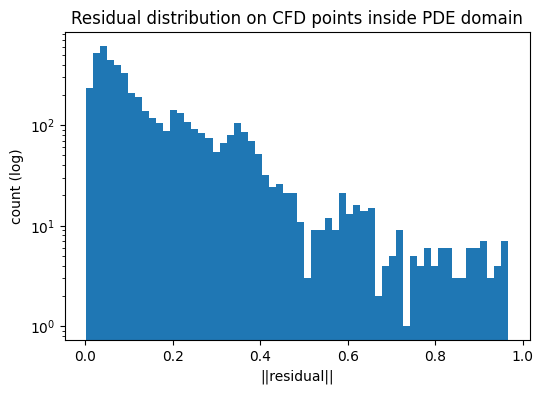

In [24]:
plt.figure(figsize=(6,4))
plt.hist(residual, bins=60, log=True)
plt.xlabel('||residual||')
plt.ylabel('count (log)')
plt.title('Residual distribution on CFD points inside PDE domain')
plt.show()


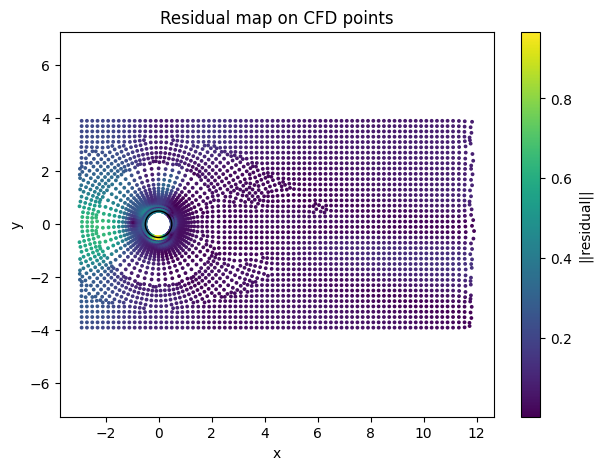

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(x_np, y_np, c=residual, s=3)
plt.colorbar(label='||residual||')
plt.gca().add_patch(plt.Circle((0,0), 0.5, fill=False, color='k'))
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Residual map on CFD points')
plt.show()


## Interpretation

- If **inside PDE fluid domain / total CFD points** is close to 1, then the reduced PDE domain still covers almost all CFD points.
- If the fraction is much smaller than 1, then the domain was reduced too aggressively.
- For residuals, watch both:
  - the **mean/median** level,
  - and the **tail fraction** above thresholds such as `1e-2` or `1e-3`.

That tells you not only average fit, but also whether there are localized bad regions (often near the cylinder and near wake separation).
